In [1]:
!uv sync --quiet

import torch
import math
import timeit
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import gc

from pytorch_nd_semiconv import SelectSemifield, QuadraticKernelSpectral2D

In [2]:
# Move to project root
from pathlib import Path
import os

if not Path("./src").is_dir():
    for parent_path in Path.cwd().parents:
        if (parent_path / "src").is_dir():
            os.chdir(parent_path)
            break
    else:
        raise FileNotFoundError("Can't find project root")

assert Path("./src").is_dir()

In [3]:
from src import load_data

In [50]:
torch.manual_seed(0)
kmnist_data = load_data.k_mnist().x_train.cuda()
cifar10_data = load_data.cifar10().x_train.cuda()
rand_km_data = torch.rand_like(kmnist_data)
rand_data_small = torch.rand((2048, 20, 12, 12)).cuda()
rand_data_med = torch.rand((2048, 32, 32, 32)).cuda()
rand_data_large = torch.rand((2048, 50, 128, 128)).cuda()

In [43]:
def time_conv(
        conv,
        imgs: torch.Tensor,
        kernels: torch.Tensor,
        target_time: float = 1.0,
        cudagraphs: bool = True,
        **kwargs,
):
    imgs, kernels = imgs.cuda(), kernels.cuda()

    gc.collect()
    torch.cuda.empty_cache()

    if cudagraphs:
        # noinspection PyProtectedMember
        torch._dynamo.reset()
        torch.compiler.cudagraph_mark_step_begin()
        conv = torch.compile(conv, mode="reduce-overhead", fullgraph=True)

    res = conv(imgs, kernels, **kwargs)
    gradient = torch.randn_like(res)
    res.backward(gradient)

    extra_kwargs = ", ".join(f"{name}={val}" for name, val in kwargs.items())
    code = f"""
res = conv(imgs, kernels, {extra_kwargs})
res.backward(gradient)
sync()
"""
    timer = timeit.Timer(
        code,
        globals={
            "conv": conv,
            "imgs": imgs,
            "kernels": kernels,
            "gradient": gradient,
            "sync": torch.cuda.synchronize,
        },
    )
    timer.timeit(2)
    autorange_runs, autorange_time = timer.autorange()
    target_runs = math.ceil(autorange_runs / autorange_time * target_time / 2)
    if target_runs < 10:
        print(f"warning: {target_runs =}")

    # Run it twice to reduce the effects of interference
    return min(timer.repeat(2, target_runs)) / target_runs

In [44]:
inflate_sizes = (1, 2, 4, 8, 16, 32, 48, 64, 92, 128)

In [73]:
def inflation_timings(imgs: torch.Tensor, kernel_size: int, disable_bar: bool = False, **kwargs):
    channels = imgs.shape[1]
    imgs = imgs.detach().clone().cuda().requires_grad_(True)
    torch.manual_seed(2)
    kernels = QuadraticKernelSpectral2D(1, channels, kernel_size)().detach().clone().cuda().requires_grad_(True)
    if kernel_size % 2:
        padding = kernel_size // 2
    else:
        padding = (kernel_size // 2 - 1, kernel_size // 2)

    return [
        time_conv(
            SelectSemifield.tropical_max().lazy_fixed(kernel_inflation=size, to_extension=False),
            imgs,
            kernels,
            padding=padding,
            groups=channels,
            **kwargs,
        )
        for size in tqdm(inflate_sizes, disable=disable_bar, desc="Inflation sizes")
    ]

In [74]:
test_timings = inflation_timings(cifar10_data[:1048, :10], 3)
print(test_timings)

Inflation sizes:   0%|          | 0/10 [00:00<?, ?it/s]

[0.0037686085752462605, 0.0030841048656608354, 0.003338838066003961, 0.0032232407523441085, 0.0031901900645121203, 0.003202824420059104, 0.003209569000023908, 0.0032033520365574025, 0.0032078200542711446, 0.0032209433225725997]


In [75]:
def inflation_plot(inflation_data: list[float] | dict[str, list[float]], title: str, ax: plt.Axes = None):
    if isinstance(inflation_data, list):
        inflation_data = {"": inflation_data}

    if ax is None:
        _, ax = plt.subplots(layout="compressed")

    ax.set_title(title)
    for label, data in inflation_data.items():
        color = ax.plot(inflate_sizes, data, label=label, linestyle="dashed")[0].get_color()
        best = np.argmin(data)
        ax.scatter(inflate_sizes[:best], data[:best], color=color)
        ax.scatter(inflate_sizes[best+1:], data[best+1:], color=color)
        ax.scatter(inflate_sizes[best], data[best], marker="x", s=100, color=color)

    if label:
        ax.legend()
    ax.set_xscale("log", base=2)
    ax.set_yscale("log", base=10)
    ax.set_xlabel("Kernel inflation coefficient in backwards pass")
    ax.set_ylabel("Runtime in seconds")

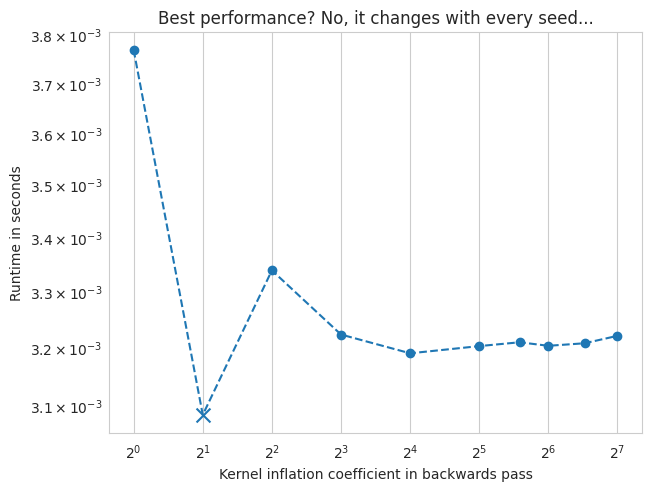

In [78]:
inflation_plot(test_timings, "Best performance? No, it changes with every seed...")